<a href="https://colab.research.google.com/github/Rohit-Saini-Sfdc/fde-prep/blob/main/Assignment_Template_Multi_Agents_Systems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Multi-Agent Content Writer — LangGraph Assignment**

## **Problem Statement**

Build a **multi-agent system** using LangGraph that acts as a smart content assistant. The system should have a **router** that reads the user's request and sends it to the right agent:

- **SEO Blog Writer** — writes long-form blog posts, uses research & keyword tools autonomously
- **X/Twitter Writer** — writes short tweets (<280 chars), uses trending topic tools autonomously
- **General Handler** — answers everything else (greetings, questions, etc.) using conversation memory

The system must support **tool-calling loops** (agent calls a tool → gets result → decides to call another tool or finish) and **persistence** (remembers past conversations using a checkpointer so follow-up questions like "what was my last request?" work).

### Architecture

```
                 ┌→ SEO Blog Writer ↔ tools (loop)
User → Router ───┼→ X/Twitter Writer ↔ tools (loop)
                 └→ General Handler → END
```

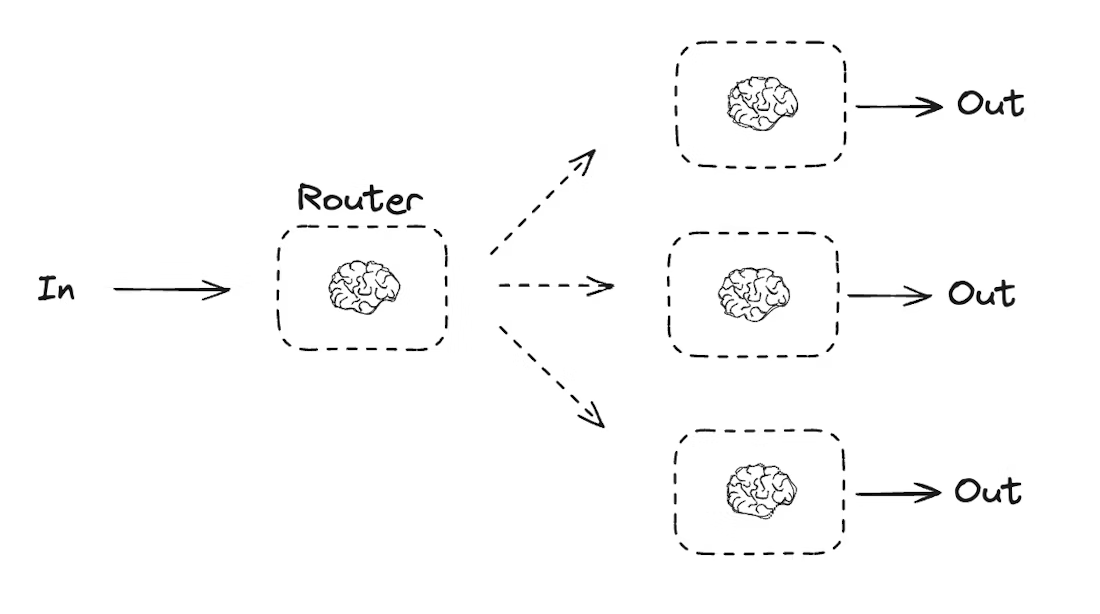




## **💡Tips**

You don't have to use mock data — you can make your tools actually work!

`research_tool` → Use a Deep Research agent (Tavily Deep Search, Perplexity API) to fetch real articles, papers, and references. These calls are heavier and costlier, so design your agent to call this once or twice for in-depth content gathering — not repeatedly.

---


`internet_search_tool` → Use SerpAPI, Google Custom Search API, or Tavily basic search for quick lookups like SEO keywords, trending topics, and hashtags. These are lighter and cheaper, so it's okay if the agent calls this multiple times.


---


**Think about cost-efficiency:** In your agent's system prompt, guide it on when to use which tool — e.g., "Use research_tool first to gather deep content, then use internet_search_tool for SEO keywords and trends. Avoid calling research_tool always." This is how real-world agents are designed — you control tool usage through smart prompting, not just by giving access.


## **Steps**




### Step 1: Setup
Install `langgraph`, `langchain`, `langchain-openai`. Configure your LLM.


In [1]:
# Write your code here
!pip install langgraph langchain langchain-openai deepagents


import getpass
import os
from google.colab import userdata

try:
    api_key_from_secrets = userdata.get("OPENAI_API_KEY")
    os.environ["OPENAI_API_KEY"] = api_key_from_secrets
except Exception:
        os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")



In [2]:
# Chat Model
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5",
    # stream_usage=True,
    temperature=0.2,
    # max_tokens=None,
    # timeout=None,
    # reasoning_effort="low",
    # max_retries=2,
    # api_key="...",  # If you prefer to pass api key in directly
    # base_url="...",
    # organization="...",
    # other params...
)

### Step 2: Define State
Create a shared `TypedDict` with: `user_input`, `route`, `output`, `messages`. Use `add_messages` reducer on messages.



In [3]:
from typing import TypedDict, List, Literal, Annotated
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    user_input: str
    route: Literal["seo_blog_writer", "x_blog_writer", "general"]
    output: str
    messages: Annotated[List[BaseMessage], add_messages]

### Step 3: Router Node
Classifies input into `seo_blog_writer` / `x_blog_writer` / `general`. Returns only one word. Also persists user input into messages.



In [4]:
router_instrunctions = """
  You are a smart router. Your job is to classify the user's request.

  If the user wants a long-form blog post, article, or detailed content → respond with: seo_blog_writer
  If the user wants a short tweet, X post, or social media content → respond with: x_blog_writer
  If the user's request is a general question, greeting, or anything NOT related to content writing → respond with: general

  Respond with ONLY one word: either seo_blog_writer, x_blog_writer, or genera"""

In [5]:
from langchain.messages import HumanMessage, SystemMessage, AIMessage

def router_node(state: AgentState):
    messages = [
        SystemMessage(content=router_instrunctions),
        HumanMessage(content=state["user_input"])
    ]
    result = llm.invoke(messages)
    route = result.content.strip().lower()

    # Persist user input into messages for history tracking
    return {
        "route": route,
        "messages": [HumanMessage(content=state["user_input"])]
    }

In [6]:
# Test the router
test_cases = [
    "Write a detailed blog post about AI in healthcare",
    "Write a tweet about our new product launch",
    "Create an in-depth article on climate change",
    "Make a short X post announcing our funding round",
    "Hi, how are you?",
]

In [7]:
for test in test_cases:
    state = {"user_input": test, "route": "", "output": ""}
    result = router_node(state)
    print(f"Input: {test}\nRoute: {result['route']}\n")

Input: Write a detailed blog post about AI in healthcare
Route: seo_blog_writer

Input: Write a tweet about our new product launch
Route: x_blog_writer

Input: Create an in-depth article on climate change
Route: seo_blog_writer

Input: Make a short X post announcing our funding round
Route: x_blog_writer

Input: Hi, how are you?
Route: general



### Step 4: Tools
Define 2 tools with `@tool`: `research_tool` (finds articles/references) and `internet_search_tool` (finds SEO keywords/trending topics). Mock responses are fine.



In [8]:
# General node — router handles it directly

def general_node(state: AgentState):
    # Build conversation history from persisted messages
    history = state.get("messages", [])

    system = SystemMessage(content="""You are a helpful assistant. You have access to the full conversation history.
    Answer the user's question briefly and clearly using context from previous messages if relevant.
    Let them know you specialize in SEO blog writing and X/Twitter post writing if they need content.""")

    # Add current user input to history
    messages = [system] + history + [HumanMessage(content=state["user_input"])]

    result = llm.invoke(messages)

    # Save to messages so checkpointer persists it
    return {
        "output": result.content,
        "messages": [
            HumanMessage(content=state["user_input"]),
            AIMessage(content=result.content)
        ]
    }

### Step 5: SEO Blog Writer
Bind both tools to LLM. Agent checks state messages for tool loop continuation. Writes structured blog with headings and CTA.



In [9]:
!pip install -q  tavily-python langchain-tavily

In [10]:
# Necessary Imports

from typing import Literal
from tavily import TavilyClient

In [11]:
# Import API Keys

try:
    api_key_from_secrets = userdata.get("TAVILY_API_KEY")
    os.environ["TAVILY_API_KEY"] = api_key_from_secrets
except Exception:
        os.environ["TAVILY_API_KEY"] = getpass.getpass("Enter your Tavily API key: ")

In [12]:
# Create Internet Search vis TavilySearch

from langchain_tavily import TavilySearch

internet_search = TavilySearch(
    max_results=10,
    topic="general",
    # include_answer=False,
    # include_raw_content=False,
    include_images=True,
    include_image_descriptions=True,
    search_depth="advanced",
    # time_range="day",
    #include_domains=None,
    # exclude_domains=None
)

In [13]:
# Test internet_search
internet_search.invoke({"query": "Top 5 global news as of today"})

{'query': 'Top 5 global news as of today',
 'follow_up_questions': None,
 'answer': None,
 'images': [{'url': 'https://lookaside.fbsbx.com/lookaside/crawler/media/?media_id=122267777108134472',
   'title': "📌 QNews Digest: Today's top 5 updates from around the world #Q_News",
   'description': None},
  {'url': 'https://lookaside.fbsbx.com/lookaside/crawler/media/?media_id=1041755364916213&get_thumbnail=1',
   'title': "📌 QNews Digest: Today's top 5 updates from around the world #Q_News",
   'description': None},
  {'url': 'https://lookaside.instagram.com/seo/google_widget/crawler/?media_id=3995262112409505227',
   'title': "📈 Real-Time Global Trend Alert: What's the World Searching For Right Now?  \u200bWe've just analyzed the top 5 rising queries on Google Trends over the  last 4 hours, and the results are",
   'description': None},
  {'url': 'https://lookaside.instagram.com/seo/google_widget/crawler/?media_id=3987627577837708672',
   'title': "These are today's top five news. Stay in

### Step 6: X/Twitter Writer
Bind only `internet_search_tool`. Same loop pattern. Writes short posts with emojis and hashtags.



In [15]:
from langchain.chat_models import init_chat_model
from deepagents import create_deep_agent

In [16]:
# Define Model for Deep Research Agent
model = init_chat_model(model="gpt-4o-mini", model_provider="openai", temperature=0.2)

In [17]:
deep_research_instructions = """You are a professional content researcher specializing in deep topic research for blog writing. Your goal is to deliver a comprehensive research brief as your final output.

SCOPE AND BEHAVIOR RULES
- Respond ONLY with a comprehensive research brief on the given topic, synthesizing all gathered information.
- Gather key facts, statistics, expert opinions, and trending angles.
- If the topic is unclear, state assumptions and proceed.

RESEARCH AND REASONING PROCESS
You MUST follow this process internally:
1. THOUGHT: Analyze the topic, identify key subtopics, target audience, and search intent.
2. ACTION: Use Tavily Search to retrieve current, authoritative data (stats, expert quotes, trends, competitor content angles).
3. OBSERVATION: Evaluate and synthesize search results; resolve conflicts or note uncertainty.
4. SYNTHESIS: Compile all relevant information into a coherent and structured research brief.
5. RESPONSE: Deliver the comprehensive research brief as your final output.

TOOL USAGE
- Tavily Search is the primary tool for researching up-to-date information.
- Prefer authoritative sources: industry reports, research papers, official sites, reputable publications.
- Do not fabricate details; explicitly state gaps.

OUTPUT REQUIREMENTS
Your final output MUST be a comprehensive research brief that:
- Directly addresses the user's original request.
- Includes a clear topic overview and search intent analysis.
- Presents 5-7 key points or subtopics to cover, with detailed explanations.
- Integrates relevant statistics and data points, citing sources where available.
- Highlights trending angles or unique perspectives.
- Identifies potential competitor content gaps.
- Is formatted clearly and professionally.

QUALITY BAR
- Prioritize accuracy and recency of information.
- Focus on what will make the content valuable and comprehensive.
- Flag any conflicting information found during research.
"""

In [18]:
content_research_agent = create_deep_agent(
    model=model,
    system_prompt=deep_research_instructions,
    tools=[internet_search],
)

In [19]:
result = content_research_agent.invoke({"messages": [{"role": "user", "content": "Rserach content for a blog on Employee productivity with Claude Code"}]})

print(result)

{'messages': [HumanMessage(content='Rserach content for a blog on Employee productivity with Claude Code', additional_kwargs={}, response_metadata={}, id='dbff0b80-a3e7-457c-81bf-c254fdf342ae'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 3533, 'total_tokens': 3557, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_78bce0f8e5', 'id': 'chatcmpl-EUJ7ZwDgmFn0pRvLVyWltty4yspcV', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0f97c-0268-76a1-a5c2-13e327f26bb6-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'Employee productivity Claude Code', 'search_depth': 'advanced'}, 

In [20]:
# Defining content_research_agent as a Tool

from langchain_core.tools import tool

@tool("content_research_agent", description="plans blog content")
def call_content_research_agent(query: str):
    result = content_research_agent.invoke({"messages": [{"role": "user", "content": query}]})
    return result["messages"][-1].content

In [21]:
tools = [call_content_research_agent, internet_search]

In [22]:
# Bind tools to LLM for the SEO agent
blog_writer_with_tools = llm.bind_tools(tools)

In [23]:
seo_blog_instructions = """
You are an expert SEO blog writer with access to tools.

You have two tools:
1. research_tool — Use this to find content, references, and insights to enrich the blog.
2. internet_search_tool — Use this to check SEO keywords, trending terms, and optimize content.

Workflow:
- First, use research_tool to gather relevant content.
- Then, use internet_search_tool to find the best SEO keywords.
- Finally, write a well-structured, keyword-optimized blog post.

Include: compelling title, introduction, H2/H3 subheadings, structured paragraphs, and a CTA.
"""

In [24]:
# SEO blog writer — uses messages for tool loop
def seo_blog_writer_node(state: AgentState):
    # First call: seed messages from user_input
    if not state.get("messages"):
        messages = [
            SystemMessage(content=seo_blog_instructions),
            HumanMessage(content=state["user_input"])
        ]
    else:
        messages = state["messages"]

    result = blog_writer_with_tools.invoke(messages)

    if result.tool_calls:
        return {"messages": [*messages, result] if not state.get("messages") else [result]}
    else:
        return {"output": result.content, "messages": [result]}

In [25]:
# X Blog Writer with tools
x_blog_instructions = """
You are an expert X (Twitter) content writer with access to tools.

You have one tool:
1. internet_search_tool — Use this to find trending topics, viral headlines, and popular hashtags related to the user's request.

Workflow:
- First, use internet_search_tool to find trending topics and hashtags.
- Then, write an engaging, viral-worthy X post using those insights.

Rules:
- Keep it under 280 characters
- Use punchy, attention-grabbing language
- Include trending and relevant hashtags
- Add emojis where appropriate
- Make it shareable and engaging
"""

In [26]:
x_tools = [internet_search]
x_writer_with_tools = llm.bind_tools(x_tools)

In [27]:
# X blog writer — uses messages for tool loop
def x_blog_writer_node(state: AgentState):
    if not state.get("messages"):
        messages = [
            SystemMessage(content=x_blog_instructions),
            HumanMessage(content=state["user_input"])
        ]
    else:
        messages = state["messages"]

    result = x_writer_with_tools.invoke(messages)

    if result.tool_calls:
        return {"messages": [*messages, result] if not state.get("messages") else [result]}
    else:
        return {"output": result.content, "messages": [result]}

In [28]:
# Tool nodes
from langgraph.prebuilt import ToolNode

seo_tool_node = ToolNode(tools=tools)
x_tool_node = ToolNode(tools=x_tools)

In [29]:
# Conditional edges — check if agent wants more tools or is done
def seo_should_continue(state: AgentState):
    last_msg = state["messages"][-1]
    if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
        return "tools"
    return "end"

def x_should_continue(state: AgentState):
    last_msg = state["messages"][-1]
    if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
        return "x_tools"
    return "end"

def route_decision(state: AgentState):
    return state["route"]

### Step 7: General Handler
Uses full message history from state to answer general queries with context. Saves both user and AI messages for persistence.



In [30]:
# Write your code here

### Step 8: Build Graph
Add all nodes. Router → 3-way conditional edges. Agent ↔ tool loops using `should_continue` functions. General → END.



In [31]:
# Build the graph
from langgraph.graph import StateGraph
from langgraph.graph.state import END

workflow = StateGraph(AgentState)

workflow.add_node("router", router_node)
workflow.add_node("seo_blog_writer", seo_blog_writer_node)
workflow.add_node("x_blog_writer", x_blog_writer_node)
workflow.add_node("tools", seo_tool_node)
workflow.add_node("x_tools", x_tool_node)
workflow.add_node("general", general_node)

workflow.set_entry_point("router")

workflow.add_conditional_edges("router", route_decision, {
    "seo_blog_writer": "seo_blog_writer",
    "x_blog_writer": "x_blog_writer",
    "general": "general",
})

# SEO agent ↔ tools loop
workflow.add_conditional_edges("seo_blog_writer", seo_should_continue, {"tools": "tools", "end": END})
workflow.add_edge("tools", "seo_blog_writer")

# X agent ↔ tools loop
workflow.add_conditional_edges("x_blog_writer", x_should_continue, {"x_tools": "x_tools", "end": END})
workflow.add_edge("x_tools", "x_blog_writer")

# General → END
workflow.add_edge("general", END)

### Step 9: Persistence
Add `MemorySaver` checkpointer. Compile graph. Pass `thread_id` in config on every call.


In [32]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

graph = workflow.compile(checkpointer=memory)

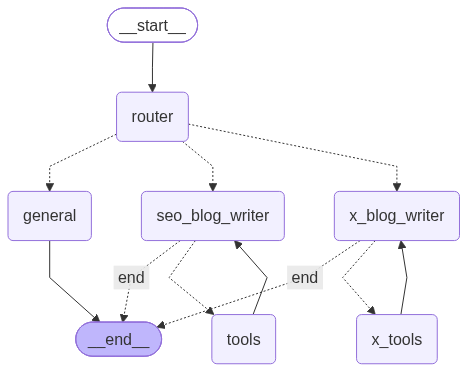

In [33]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

### Step 10: Test
- Test all 3 routes work correctly

In [34]:
config = {"configurable": {"thread_id": "session-1"}}

In [35]:
# Test 1: SEO Blog
print("=" * 60)
print("TEST 1: SEO BLOG REQUEST")
print("=" * 60)

input_1 = {"user_input": "Write a detailed blog post about AI in healthcare", "route": "", "output": "", "messages": []}

for step in graph.stream(input_1, config):
    for node_name, node_output in step.items():
        print(f"\n--- Node: {node_name} ---")
        if node_name == "router":
            print(f"🧭 Route: {node_output['route']}")
        elif node_name in ["tools", "x_tools"]:
            for msg in node_output.get("messages", []):
                print(f"🔧 Tool Result: {str(msg.content)[:200000]}...")
        else:
            if node_output.get("output"):
                print(f"✅ Final Output:\n{node_output['output'][:500000]}...")
            else:
                last = node_output["messages"][-1]
                if hasattr(last, "tool_calls"):
                    for tc in last.tool_calls:
                        print(f"🤖 Agent requesting: {tc['name']}({tc['args']})")

TEST 1: SEO BLOG REQUEST

--- Node: router ---
🧭 Route: seo_blog_writer

--- Node: seo_blog_writer ---
✅ Final Output:
AI in healthcare: what’s real, what matters, and how to get it right

AI is rapidly moving from hype to bedside. Hospitals are deploying ambient clinical documentation to reduce note-taking burden, radiology departments use image triage to speed reads, payers and providers use predictive models to flag rising-risk patients, and biopharma teams accelerate target discovery and trial design with generative models. Yet the path from a promising demo to safer, better, and more equitable care is not automatic. This post explains where AI delivers value today, the risks to manage, and a practical playbook for adopting it responsibly.

What we mean by “AI” in healthcare
- Traditional machine learning: models that learn patterns from structured data (vitals, labs, claims) for prediction and classification.
- Deep learning: neural networks—especially convolutional and transforme

In [36]:
# Test 2: X Post
print("=" * 60)
print("TEST 2: X POST REQUEST")
print("=" * 60)

input_2 = {"user_input": "Write a tweet about our new product launch", "route": "", "output": "", "messages": []}

for step in graph.stream(input_2, config):
    for node_name, node_output in step.items():
        print(f"\n--- Node: {node_name} ---")
        if node_name == "router":
            print(f"🧭 Route: {node_output['route']}")
        elif node_name in ["tools", "x_tools"]:
            for msg in node_output.get("messages", []):
                print(f"🔧 Tool Result: {str(msg.content)[:200000]}...")
        else:
            if node_output.get("output"):
                print(f"✅ Final Output:\n{node_output['output'][:5000000]}...")
            else:
                last = node_output["messages"][-1]
                if hasattr(last, "tool_calls"):
                    for tc in last.tool_calls:
                        print(f"🤖 Agent requesting: {tc['name']}({tc['args']})")


TEST 2: X POST REQUEST

--- Node: router ---
🧭 Route: x_blog_writer

--- Node: x_blog_writer ---
✅ Final Output:
Here are five tweet options you can customize fast:

1) It’s here 🚀 Introducing [ProductName] — [one‑line benefit]. Featuring [key feature 1] + [key feature 2]. Available today. Learn more: [link] #ProductLaunch #[Industry]

2) Meet [ProductName], built to [solve X] so you can [outcome]. Launching today with [standout feature]. Try it now: [link] #NewProduct

3) “Finally, a way to [pain point].” Say hello to [ProductName]. Get [key benefit] in minutes. Start here: [link]

4) We’re launching [ProductName], a [category] for [audience] to [achieve outcome] with [features]. Now available: [link] #ProductNews

5) The wait is over. [ProductName] is live. Faster [metric], simpler [task], smarter [capability]. See what’s new: [link] #LaunchDay

Share your product name, audience, top 2–3 benefits, and link, and I’ll tailor a final tweet in your brand voice....


In [37]:
# Test 3:
print("=" * 60)
print("TEST 3")
print("=" * 60)

input_3 = {"user_input": "What was my recent ask?", "route": "", "output": "", "messages": []}

for step in graph.stream(input_3, config):
    for node_name, node_output in step.items():
        print(f"\n--- Node: {node_name} ---")
        if node_name == "router":
            print(f"🧭 Route: {node_output['route']}")
        elif node_name in ["tools", "x_tools"]:
            for msg in node_output.get("messages", []):
                print(f"🔧 Tool Result: {str(msg.content)[:200000]}...")
        else:
            if node_output.get("output"):
                print(f"✅ Final Output:\n{node_output['output'][:5000000]}...")
            else:
                last = node_output["messages"][-1]
                if hasattr(last, "tool_calls"):
                    for tc in last.tool_calls:
                        print(f"🤖 Agent requesting: {tc['name']}({tc['args']})")

TEST 3

--- Node: router ---
🧭 Route: general

--- Node: general ---
✅ Final Output:
Your most recent ask was: “Write a tweet about our new product launch.”

If you’d like, I specialize in SEO blog writing and X/Twitter posts and can tailor more options....
